# Seasonal Agriculture Performance Analysis

# Major Data Analytics Project

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, Numpy, Matplotlib

**Project Goal:**

Investigate:

•	How does agricultural performance vary across seasons?  
•	What major seasonal patterns can be observed?  
•	Which characteristics change between seasons?  
•	Differences in available data

Note:This is Data analytics project.No machine learning or dashboard development used.


# 1.Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.


# Project Objectives
•	Explore and understand the dataset.  
•	Clean and prepare the data for analysis.  
•	Examine how agricultural performance varies across seasons.  
•	Identify important seasonal patterns and trends.  
•	Investigate relationships between seasonal conditions and agricultural outcomes.  
•	Compare relevant groups within different seasons.  
•	Identify significant differences or unusual patterns.  
•	Apply appropriate statistical and visualization techniques.  
•	Interpret findings based on evidence from the dataset.  
•	Develop meaningful conclusions and data-driven recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [23]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset (2).csv to seasonal_agriculture_performance_dataset (2) (1).csv


In [21]:
df = pd.read_csv("seasonal_agriculture_performance_dataset (2).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Dataset Overview

In [22]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


The first five rows were examined to understand the structure and
variables present in the dataset.

## 4. Dataset Shape and Structure

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 4000
Number of columns: 28
Dataset shape: (4000, 28)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

The dataset structure and data types were examined to understand the
available numerical and categorical variables.

## 5. Data Types

In [6]:
print("Numeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

Numeric columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 6. Missing Value Analysis

In [7]:
missing = df.isnull().sum()

print("Missing values by column:")
print(missing[missing > 0])

print("\nTotal missing values:", missing.sum())

Missing values by column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing values: 120


In [24]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

print("Rainfall and soil moisture missing values handled.")
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Rainfall and soil moisture missing values handled.
Remaining missing values:
Yield_Tonnes_Ha    32
dtype: int64


### Missing Value Handling

Missing values were identified in rainfall, soil moisture and yield.

Median imputation was used for rainfall and soil moisture because they
are continuous environmental variables.

Missing yield values were not artificially imputed because yield is a
primary performance variable. Rows with missing yield are excluded only
from analyses that require yield.

## 7. Duplicate Record Analysis

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

Duplicate records: 0
No duplicate records found.


## 8. Descriptive Statistical Analysis

In [25]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [26]:
print("Mean:")
print(df.select_dtypes(include=np.number).mean())

print("\nMedian:")
print(df.select_dtypes(include=np.number).median())

print("\nStandard Deviation:")
print(df.select_dtypes(include=np.number).std())

Mean:
Farm_Area_Hectares                    7.888265
Rainfall_mm                         600.922825
Avg_Temperature_C                    26.818900
Humidity_pct                         63.210500
Sunlight_Hours_Day                    7.323050
Soil_pH                               6.701010
Soil_Moisture_pct                    26.507150
Nitrogen_kg_ha                      120.250825
Phosphorus_kg_ha                     57.781850
Potassium_kg_ha                     104.760050
Fertilizer_kg_ha                    186.036000
Pesticide_Litre_ha                    5.070935
Seed_Quality_Score                    0.826138
Yield_Tonnes_Ha                       5.270595
Production_Tonnes                    43.246210
Market_Price_INR_Tonne            44714.166250
Total_Cost_INR                   526303.583000
Revenue_INR                      637860.048000
Profit_INR                       111556.465000
Water_Used_m3                      6045.570250
Water_Efficiency_t_per_1000m3         5.385214
Disease

Descriptive statistics were calculated to understand the central
tendency and variation of the numerical variables in the dataset.

## 9. Outlier Analysis

In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_table = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Variable", "Number_of_Outliers"]
)

outlier_table.sort_values(
    "Number_of_Outliers",
    ascending=False
)

,Variable,Number_of_Outliers
18,Profit_INR,404
14,Production_Tonnes,333
20,Water_Efficiency_t_per_1000m3,322
13,Yield_Tonnes_Ha,302
19,Water_Used_m3,276
17,Revenue_INR,240
9,Potassium_kg_ha,32
4,Sunlight_Hours_Day,26
8,Phosphorus_kg_ha,16
10,Fertilizer_kg_ha,15


### Outlier Analysis

The IQR method was used to identify potential outliers in numerical
variables.

Outliers were investigated rather than automatically removed because
extreme agricultural observations may represent genuine differences
in farming conditions.

# 10. Univariate Analysis

## Agricultural Yield Distribution

The distribution of agricultural yield is analyzed to understand its
central tendency and variation.

In [27]:
yield_df = df.dropna(subset=["Yield_Tonnes_Ha"])

print("Mean:", yield_df["Yield_Tonnes_Ha"].mean())
print("Median:", yield_df["Yield_Tonnes_Ha"].median())
print("Minimum:", yield_df["Yield_Tonnes_Ha"].min())
print("Maximum:", yield_df["Yield_Tonnes_Ha"].max())

Mean: 5.270594758064516
Median: 1.74
Minimum: 0.3
Maximum: 101.44


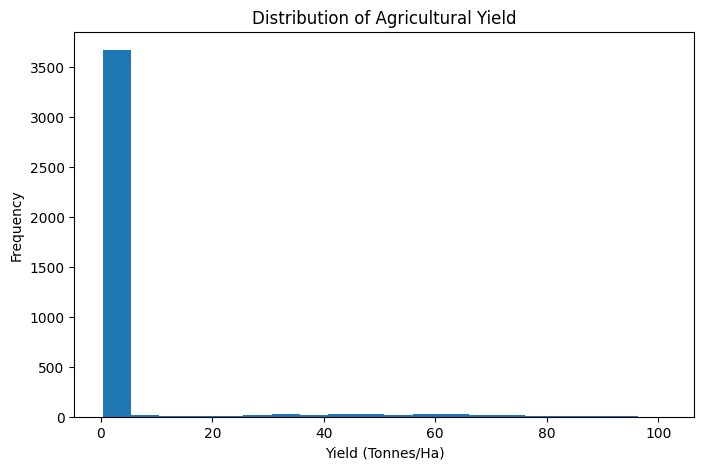

In [28]:
plt.figure(figsize=(8,5))

plt.hist(yield_df["Yield_Tonnes_Ha"], bins=20)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.show()

### Finding

The histogram shows the distribution and variation of agricultural
yield across the available observations.

# 11. Analysis 1

## Seasonal Yield Performance

### Objective

To compare average agricultural yield across different seasons.


In [29]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print("Average Yield by Season:")
print(season_yield)

Average Yield by Season:
Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


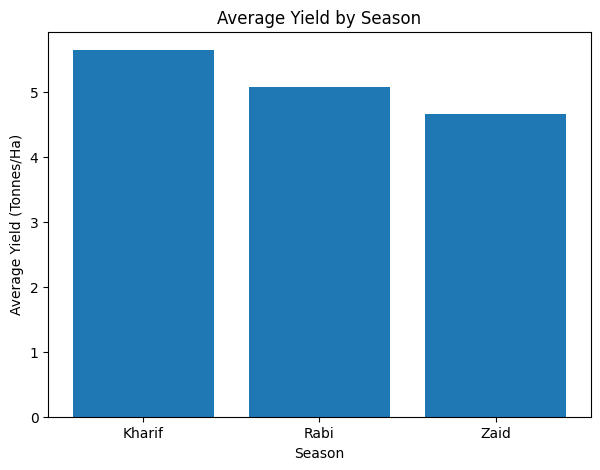

In [30]:
plt.figure(figsize=(7,5))

plt.bar(season_yield.index, season_yield.values)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.show()

### Finding

The average agricultural yield differs across seasons. Kharif records
the highest average yield, while Zaid records the lowest average yield.

# 12. Bivariate Analysis

## Relationship Between Yield and Profit

This analysis examines the relationship between agricultural yield and
profit.

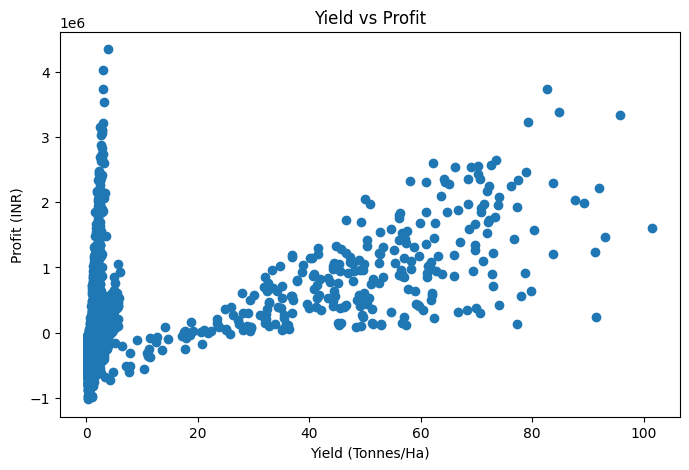

In [31]:
bivariate_df = df.dropna(
    subset=["Yield_Tonnes_Ha", "Profit_INR"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    bivariate_df["Yield_Tonnes_Ha"],
    bivariate_df["Profit_INR"]
)

plt.title("Yield vs Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")

plt.show()

In [32]:
print(
    "Correlation between Yield and Profit:",
    bivariate_df["Yield_Tonnes_Ha"].corr(
        bivariate_df["Profit_INR"]
    )
)

Correlation between Yield and Profit: 0.48982238097591435


### Finding

The scatter plot shows the relationship between agricultural yield and
profit. The correlation value indicates the strength and direction of
their linear relationship in the available data.

# 13. Analysis 2

## Seasonal Economic Performance

### Objective

To compare revenue, total cost and profit across different seasons.

In [33]:
economic = df.groupby("Season")[[
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR"
]].mean()

print("Average Economic Performance by Season:")
print(economic)

Average Economic Performance by Season:
          Revenue_INR  Total_Cost_INR     Profit_INR
Season                                              
Kharif  710719.055649   531804.408094  178914.647555
Rabi    601526.048556   513836.578365   87689.470191
Zaid    519171.904040   543976.728956  -24804.824916


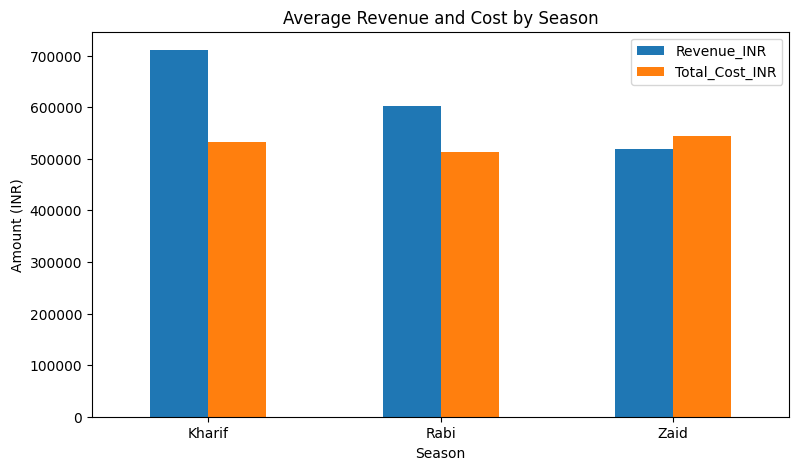

In [34]:
economic[[
    "Revenue_INR",
    "Total_Cost_INR"
]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Revenue and Cost by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)

plt.show()

In [35]:
print("Average Profit by Season:")
print(economic["Profit_INR"])

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


### Finding

Economic performance differs across seasons. Kharif records the highest
average profit, while Zaid shows the weakest economic performance.

# 14. Analysis 3

## Seasonal Water Usage and Efficiency

### Objective

To compare water usage and water-use efficiency across different
seasons.

In [42]:
water = df.groupby("Season")[[
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]].mean()

print("Average Water Usage and Efficiency by Season:")
print(water)

Average Water Usage and Efficiency by Season:
        Water_Used_m3  Water_Efficiency_t_per_1000m3
Season                                              
Kharif    6102.201237                       5.891834
Rabi      5846.987093                       5.186122
Zaid      6419.893939                       4.413239


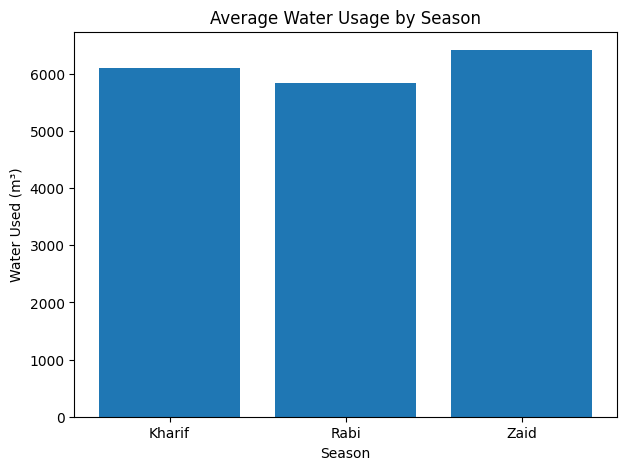

In [50]:
plt.figure(figsize=(7,5))

plt.bar(
    water.index,
    water["Water_Used_m3"]
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

In [44]:
print("Average Water Efficiency by Season:")
print(water["Water_Efficiency_t_per_1000m3"])

Average Water Efficiency by Season:
Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


### Finding

Water usage and water-use efficiency differ across seasons. Zaid
records the highest average water usage and the lowest average
water-use efficiency among the three seasons.

# 15. Multivariate Analysis

## Comparison of Multiple Agricultural Characteristics

Multiple agricultural variables are compared together across seasons
to understand differences in agricultural performance, resource usage
and environmental conditions.

In [45]:
multivariate = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Water_Used_m3",
    "Rainfall_mm",
    "Profit_INR"
]].mean()

print(multivariate)

        Yield_Tonnes_Ha  Water_Used_m3  Rainfall_mm     Profit_INR
Season                                                            
Kharif         5.643973    6102.201237   849.199663  178914.647555
Rabi           5.080498    5846.987093   437.615366   87689.470191
Zaid           4.665942    6419.893939   304.654714  -24804.824916


In [46]:
normalized = multivariate.copy()

for column in normalized.columns:
    normalized[column] = (
        normalized[column] - normalized[column].min()
    ) / (
        normalized[column].max() - normalized[column].min()
    )

print("Normalized Seasonal Comparison:")
print(normalized)

Normalized Seasonal Comparison:
        Yield_Tonnes_Ha  Water_Used_m3  Rainfall_mm  Profit_INR
Season                                                         
Kharif         1.000000       0.445472     1.000000    1.000000
Rabi           0.423868       0.000000     0.244168    0.552202
Zaid           0.000000       1.000000     0.000000    0.000000


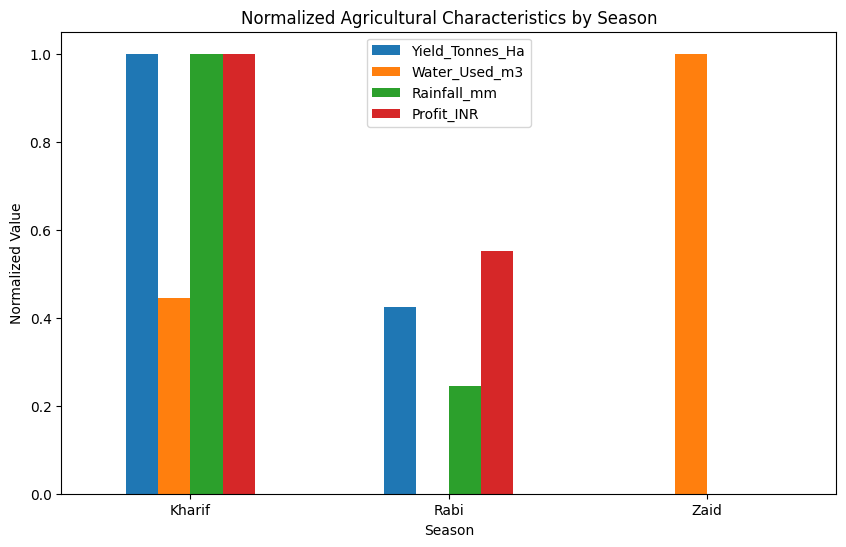

In [38]:
normalized.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Normalized Agricultural Characteristics by Season")
plt.xlabel("Season")
plt.ylabel("Normalized Value")
plt.xticks(rotation=0)

plt.show()

### Finding

The multivariate comparison shows that several agricultural
characteristics differ across seasons. Yield, water usage, rainfall
and profit show different seasonal patterns.

# 16. Correlation Analysis

Correlation analysis is performed to identify the strength and
direction of linear relationships between important numerical
agricultural variables.

In [39]:
corr_columns = [
    "Yield_Tonnes_Ha",
    "Water_Efficiency_t_per_1000m3",
    "Profit_INR",
    "Water_Used_m3",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Fertilizer_kg_ha"
]

correlation_matrix = df[corr_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                               Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3  \
Yield_Tonnes_Ha                       1.000000                       0.915438   
Water_Efficiency_t_per_1000m3         0.915438                       1.000000   
Profit_INR                            0.489822                       0.489487   
Water_Used_m3                         0.388653                       0.217081   
Rainfall_mm                           0.030545                       0.058102   
Avg_Temperature_C                     0.009349                       0.006534   
Fertilizer_kg_ha                      0.000562                       0.005077   

                               Profit_INR  Water_Used_m3  Rainfall_mm  \
Yield_Tonnes_Ha                  0.489822       0.388653     0.030545   
Water_Efficiency_t_per_1000m3    0.489487       0.217081     0.058102   
Profit_INR                       1.000000       0.190278     0.107648   
Water_Used_m3                    0.1902

In [40]:
yield_correlation = correlation_matrix[
    "Yield_Tonnes_Ha"
].sort_values(ascending=False)

print("Correlation of Variables with Yield:")
print(yield_correlation)

Correlation of Variables with Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Profit_INR                       0.489822
Water_Used_m3                    0.388653
Rainfall_mm                      0.030545
Avg_Temperature_C                0.009349
Fertilizer_kg_ha                 0.000562
Name: Yield_Tonnes_Ha, dtype: float64


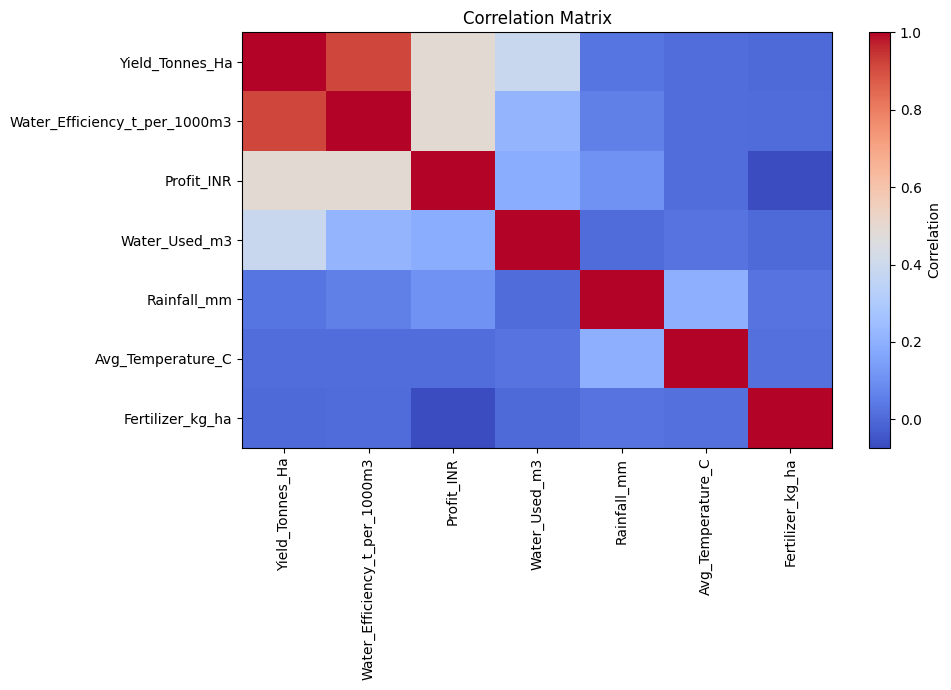

In [47]:
plt.figure(figsize=(10,7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Correlation Finding

The correlation analysis identifies the strength and direction of
relationships between important agricultural variables.

A strong positive relationship is observed between water-use efficiency
and yield in the available dataset.

Correlation indicates association and does not establish causation.

## Water Efficiency and Yield Relationship

In [48]:
correlation_value = df[
    "Water_Efficiency_t_per_1000m3"
].corr(
    df["Yield_Tonnes_Ha"]
)

print(
    "Water Efficiency vs Yield Correlation:",
    correlation_value
)

Water Efficiency vs Yield Correlation: 0.9154379390632493


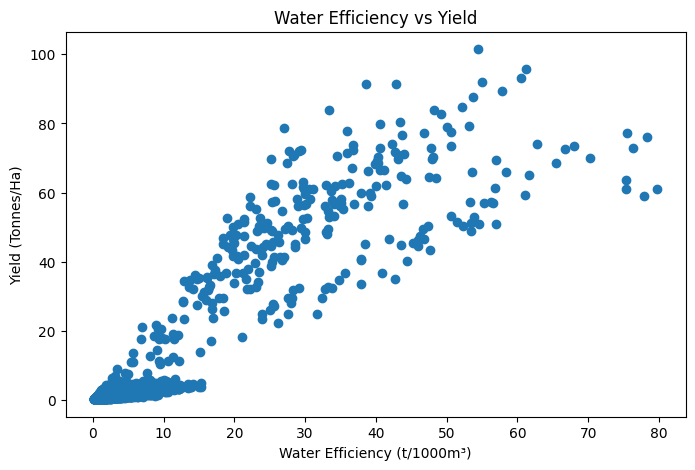

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Water_Efficiency_t_per_1000m3"],
    df["Yield_Tonnes_Ha"]
)

plt.title("Water Efficiency vs Yield")
plt.xlabel("Water Efficiency (t/1000m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Finding

The scatter plot shows a strong positive relationship between water-use
efficiency and agricultural yield in the available data.

This relationship should be interpreted as an association and not as
proof that one variable directly causes the other.

# 17. Seasonal Comparison Summary

In [41]:
season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
})

season_summary

,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.643973,710719.055649,531804.408094,178914.647555,6102.201237,5.891834
Rabi,5.080498,601526.048556,513836.578365,87689.470191,5846.987093,5.186122
Zaid,4.665942,519171.904040,543976.728956,-24804.824916,6419.893939,4.413239


The seasonal summary provides an overall comparison of agricultural
yield, economic performance, water usage and water-use efficiency across
the seasons.

# 18. Key Insights

1. Agricultural yield varies across Kharif, Rabi and Zaid seasons.

2. Kharif records the highest average agricultural yield among the
   three seasons.

3. Zaid records the lowest average agricultural yield.

4. Kharif records the highest average profit among the three seasons.

5. Zaid shows the weakest economic performance among the three seasons.

6. Zaid records the highest average water usage.

7. Zaid records the lowest average water-use efficiency.

8. Water-use efficiency has a strong positive relationship with
   agricultural yield in the available dataset.

9. Yield and profit show a positive relationship in the available data.

10. Agricultural, economic and resource-related characteristics differ
    across seasons.

# 19. Evidence-Based Recommendations

- Seasonal differences should be considered when planning agricultural
  activities and resource allocation.

- Water-use efficiency should be monitored, particularly during seasons
  with comparatively high water consumption.

- The reasons for lower yield and profitability in Zaid should be
  investigated further.

- Historical seasonal performance can support evidence-based
  agricultural planning.

- Further investigation can examine environmental and resource-related
  factors associated with differences in agricultural performance.

# 20. Limitations

- The analysis is limited to the variables available in the provided
  dataset.

- The dataset may not represent all geographical regions or farming
  conditions.

- Correlation identifies association but does not establish causation.

- External factors such as detailed soil characteristics, market
  conditions, government policies and extreme weather events may not be
  fully represented.

- Missing yield values were excluded from yield-based analyses rather
  than artificially imputed.

- The analysis is descriptive and does not involve machine learning or
  predictive modelling.

# 21. Conclusion

The analysis demonstrates that agricultural performance varies across
seasons.

Kharif shows stronger overall yield and profitability, while Zaid shows
comparatively lower yield, higher water usage and lower water-use
efficiency.

The analysis also identifies meaningful relationships between
agricultural variables, particularly the positive relationship between
water-use efficiency and yield.

Overall, data analytics and visualization were used to explore, compare
and interpret seasonal agricultural performance and generate
evidence-based insights.